In [1]:
def createRaw(data, sfreq=2048,trigger_idx=0, eeg_start=1,eeg_end=65,extra_end =89,l_freq=0.1,h_freq=40):
    orig_ch_names= [
        'Trig1',
        'A1','A2','A3','A4','A5','A6','A7','A8','A9','A10','A11','A12','A13',
        'A14','A15','A16','A17','A18','A19','A20','A21','A22','A23','A24',
        'A25','A26','A27','A28','A29','A30','A31','A32',
        'B1','B2','B3','B4','B5','B6','B7','B8','B9','B10','B11','B12','B13',
        'B14','B15','B16','B17','B18','B19','B20','B21','B22','B23','B24',
        'B25','B26','B27','B28','B29','B30','B31','B32',
        'EX1','EX2','EX3','EX4','EX5','EX6','EX7','EX8',
        'AUX1','AUX2','AUX3','AUX4','AUX5','AUX6','AUX7','AUX8',
        'AUX9','AUX10','AUX11','AUX12','AUX13','AUX14','AUX15','AUX16'
    ]
    #eeg_dataa = arr[eeg_start:eeg_end, :]
    #trigger = arr[trigger_idx, :]
    #extra_data= arr[eeg_end: extra_end, :]
# conversion of raw BioSemi ADC units (integer counts) to volts
    eeg_data, eeg_timestamps = data['BioSemi']
    
    eeg_data_volts= eeg_data* 1e-6
    #extra_data_volts = extra_data* 1e-6
    #print("Max after scaling:", np.max(np.abs(eeg_data_volts)))

# ---------------------------------------------------
# 3. Create MNE Raw object
# ---------------------------------------------------

    ch_types = ["stim"]+ ["eeg"] * (eeg_end - eeg_start) +["ecg"] * 2 + ["misc"] * 22
    print(f"  stim : {ch_types.count('stim')}")
    print(f"  eeg  : {ch_types.count('eeg')}")
    print(f"  ecg  : {ch_types.count('ecg')}")
    print(f"  misc : {ch_types.count('misc')}")
    print("EEG data shape:", eeg_data.shape)
    print("Expected channels:", len(orig_ch_names))
    # Debug: τύπος κάθε καναλιού

# Debug: τύπος κάθε καναλιού
    for name, t in zip(orig_ch_names, ch_types):
        print(f"  {name:<10} → {t}")
    #raw_data = np.vstack([trigger[None, :], eeg_data_volts, extra_data_volts])
    info = mne.create_info(ch_names=orig_ch_names, sfreq=sfreq, ch_types=ch_types)
    raw = mne.io.RawArray(eeg_data_volts, info)
    montage = mne.channels.make_standard_montage("biosemi64")
    eeg_names = montage.ch_names  
    rename_dict = {}
    for old, new in zip(orig_ch_names[eeg_start:eeg_end], eeg_names):
        rename_dict[old] = new

    raw.rename_channels(rename_dict)
    raw.set_montage(montage)
    raw.resample(128.0, npad = "auto")
    raw.filter(l_freq=l_freq, h_freq=h_freq) 
    
    raw_t0 = eeg_timestamps[0]
    return raw, raw_t0

In [2]:
def epochsCreation(
    df_sess,
    raw,
    raw_t0,
    tmin=-3.0,
    tmax=0.0
):

    sfreq = raw.info['sfreq']

    events = []
    valid_rows = []

    for _, row in df_sess.iterrows():

        sample = int(
            round((row['onset_time_s'] - raw_t0) * sfreq)
        )

        # boundary check
        start = sample + int(tmin * sfreq)
        stop  = sample + int(tmax * sfreq)

        if start >= 0 and stop < raw.n_times:

            events.append([sample, 0, 1])
            valid_rows.append(row)

    events = np.array(events, dtype=int)

    epochs = mne.Epochs(
        raw,
        events,
        event_id={'reversal': 1},
        tmin=tmin,
        tmax=tmax,
        baseline= None,
        preload=True,
        picks='eeg',
        reject_by_annotation=True
    )

    epochs.metadata = pd.DataFrame(valid_rows).reset_index(drop=True)

    return epochs

## Epochs creation from steering events with universal threshold taken with p75

In [10]:
import os
import glob
import pickle
import numpy as np
import pandas as pd
import mne

# ── Parameters ──────────────────────────────────────────────
TMIN = -3.0
TMAX = 0.0
MIN_SPACING = 3.0

CSV_PATH = (
    r"E:\koorathota_data\pkl_data\pkl_data\pkl_data\eegdata\ALL_SUBJECTS_VIS_CURVE_UNIVERSAL.csv"
)

BASE_PATH = r"E:\koorathota_data\pkl_data\pkl_data\pkl_data"

OUTPUT_DIR = (
    r"E:\koorathota_data\pkl_data\pkl_data\pkl_data\eegdata\neoskwdikas"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─────────────────────────────────────────────
# Load universal steering events
# ─────────────────────────────────────────────
df_universal = pd.read_csv(CSV_PATH)

# ─────────────────────────────────────────────
# Find all PKL files
# ─────────────────────────────────────────────
pkl_files = glob.glob(
    os.path.join(BASE_PATH, "*.pkl")
)

print(f"Found {len(pkl_files)} files")

# ─────────────────────────────────────────────
# Store ALL epochs
# ─────────────────────────────────────────────
all_epochs = []

# ─────────────────────────────────────────────
# LOOP OVER ALL FILES
# ─────────────────────────────────────────────
for file_path in pkl_files:

    file_name = os.path.basename(file_path)

    print("\n" + "=" * 60)
    print(f"Processing: {file_name}")

    try:

        # ------------------------------------------------
        # LOAD PKL
        # ------------------------------------------------
        with open(file_path, "rb") as f:
            data = pickle.load(f)

        # ------------------------------------------------
        # CREATE RAW
        # ------------------------------------------------
        raw, raw_t0 = createRaw(data)

        raw_eeg = raw.copy().pick('eeg')

        # ------------------------------------------------
        # SUBJECT / SESSION
        # ------------------------------------------------
        trial, _ = data["Unity_TrialInfo"]

        subject_id = int(trial[0][0])
        session_id = int(trial[1][0])

        print(f"Subject: {subject_id}")
        print(f"Session: {session_id}")

        # ------------------------------------------------
        # MATCH EVENTS
        # ------------------------------------------------
        df_sess = df_universal[
            (df_universal['subject_id'] == subject_id) &
            (df_universal['session_id'] == session_id)
        ].copy()

        if len(df_sess) == 0:
            print("No matching events")
            continue

        # ------------------------------------------------
        # SORT EVENTS
        # ------------------------------------------------
        df_sess = (
            df_sess
            .sort_values("onset_time_s")
            .reset_index(drop=True)
        )

        # ------------------------------------------------
        # REMOVE OVERLAPS
        # ------------------------------------------------
        keep = [True]

        for i in range(1, len(df_sess)):

            dt = (
                df_sess.iloc[i]["onset_time_s"]
                - df_sess.iloc[i - 1]["onset_time_s"]
            )

            keep.append(dt >= MIN_SPACING)

        df_sess = df_sess[np.array(keep)]

        print(f"Events after spacing: {len(df_sess)}")

        # ------------------------------------------------
        # CREATE EPOCHS
        # ------------------------------------------------
        epochs = epochsCreation(
            df_sess,
            raw_eeg,
            raw_t0,
            tmin=TMIN,
            tmax=TMAX
        )

        print(f"Created epochs: {len(epochs)}")

        # ------------------------------------------------
        # STORE
        # ------------------------------------------------
        all_epochs.append(epochs)

        # ------------------------------------------------
        # MEMORY CLEANUP
        # ------------------------------------------------
        del data
        del raw
        del raw_eeg

    except Exception as e:

        print(f"\nERROR processing: {file_name}")
        print(type(e))
        print(e)

        continue
# ─────────────────────────────────────────────
# CONCATENATE ALL SUBJECTS
# ─────────────────────────────────────────────
print("\nConcatenating all epochs...")

print("\nConcatenating all epochs...")

combined_epochs = mne.concatenate_epochs(all_epochs)

print(combined_epochs)

# ─────────────────────────────────────────────
# VERIFY METADATA
# ─────────────────────────────────────────────
print("\nMetadata columns:")
print(combined_epochs.metadata.columns)

print("\nMetadata sample:")
print(combined_epochs.metadata.head())

# ─────────────────────────────────────────────
# SAVE FINAL FILE
# ─────────────────────────────────────────────
output_path = os.path.join(
    OUTPUT_DIR,
    "eeg_epochs_with_metadata.fif"
)

combined_epochs.save(
    output_path,
    overwrite=True
)

print("\nSaved combined epochs:")
print(output_path)

Found 30 files

Processing: Copy of 08_25_2022_10_32_35-Exp_adadrive-Sbj_12-Ssn_01.dats-025.pkl
  stim : 1
  eeg  : 64
  ecg  : 2
  misc : 22
EEG data shape: (89, 3122151)
Expected channels: 89
  Trig1      → stim
  A1         → eeg
  A2         → eeg
  A3         → eeg
  A4         → eeg
  A5         → eeg
  A6         → eeg
  A7         → eeg
  A8         → eeg
  A9         → eeg
  A10        → eeg
  A11        → eeg
  A12        → eeg
  A13        → eeg
  A14        → eeg
  A15        → eeg
  A16        → eeg
  A17        → eeg
  A18        → eeg
  A19        → eeg
  A20        → eeg
  A21        → eeg
  A22        → eeg
  A23        → eeg
  A24        → eeg
  A25        → eeg
  A26        → eeg
  A27        → eeg
  A28        → eeg
  A29        → eeg
  A30        → eeg
  A31        → eeg
  A32        → eeg
  B1         → eeg
  B2         → eeg
  B3         → eeg
  B4         → eeg
  B5         → eeg
  B6         → eeg
  B7         → eeg
  B8         → eeg
  B9         → eeg
  B10  

C:\Users\USER\AppData\Local\Temp\ipykernel_15440\188028249.py:51: RuntimeWarning: Trigger channel contains negative values, using absolute value. If data were acquired on a Neuromag system with STI016 active, consider using uint_cast=True to work around an acquisition bug
  raw.resample(128.0, npad = "auto")


Trigger channel Trig1 has a non-zero initial value of {initial_value} (consider using initial_event=True to detect this event)
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 4225 samples (33.008 s)



C:\Users\USER\AppData\Local\Temp\ipykernel_15440\188028249.py:51: RuntimeWarning: Trigger channel contains negative values, using absolute value. If data were acquired on a Neuromag system with STI016 active, consider using uint_cast=True to work around an acquisition bug
  raw.resample(128.0, npad = "auto")
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    1.2s finished


Subject: 12
Session: 1
Events after spacing: 125
Not setting metadata
125 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 125 events and 385 original time points ...
0 bad epochs dropped
Adding metadata with 10 columns
Created epochs: 125

Processing: Copy of 08_26_2022_11_53_52-Exp_adadrive-Sbj_12-Ssn_02.dats-028.pkl
  stim : 1
  eeg  : 64
  ecg  : 2
  misc : 22
EEG data shape: (89, 3891602)
Expected channels: 89
  Trig1      → stim
  A1         → eeg
  A2         → eeg
  A3         → eeg
  A4         → eeg
  A5         → eeg
  A6         → eeg
  A7         → eeg
  A8         → eeg
  A9         → eeg
  A10        → eeg
  A11        → eeg
  A12        → eeg
  A13        → eeg
  A14        → eeg
  A15        → eeg
  A16        → eeg
  A17        → eeg
  A18        → eeg
  A19        → eeg
  A20        → eeg
  A21        → eeg
  A22        → eeg
  A23        → eeg
  A24        → eeg
  A25        → eeg
  A26        → eeg


...

Trigger channel Trig1 has a non-zero initial value of {initial_value} (consider using initial_event=True to detect this event)
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 4225 samples (33.008 s)



C:\Users\USER\AppData\Local\Temp\ipykernel_15440\188028249.py:51: RuntimeWarning: Trigger channel contains negative values, using absolute value. If data were acquired on a Neuromag system with STI016 active, consider using uint_cast=True to work around an acquisition bug
  raw.resample(128.0, npad = "auto")
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    0.6s finished


Subject: 23
Session: 3
Events after spacing: 146
Not setting metadata
146 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 146 events and 385 original time points ...
0 bad epochs dropped
Adding metadata with 10 columns
Created epochs: 146

Concatenating all epochs...

Concatenating all epochs...
Adding metadata with 10 columns
3372 matching events found
No baseline correction applied
<EpochsArray | 3372 events (all good), -3 – 0 s (baseline off), ~634.0 MB, data loaded, with metadata,
 'reversal': 3372>

Metadata columns:
Index(['label', 'onset_time_s', 'offset_time_s', 'duration_s',
       'amplitude_norm', 'amplitude_deg', 'direction', 'fog_density',
       'subject_id', 'session_id'],
      dtype='object')

Metadata sample:
          label  onset_time_s  offset_time_s  duration_s  amplitude_norm  \
0  visual_curve   3896.263406    3899.763406    3.500000        0.287251   
1  visual_curve   3903.786844    3905.47434

C:\Users\USER\AppData\Local\Temp\ipykernel_15440\3900854031.py:179: RuntimeWarning: This filename (E:\koorathota_data\pkl_data\pkl_data\pkl_data\eegdata\neoskwdikas\eeg_epochs_with_metadata_swstoteromallon.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  combined_epochs.save(



Saved combined epochs:
E:\koorathota_data\pkl_data\pkl_data\pkl_data\eegdata\neoskwdikas\eeg_epochs_with_metadata_swstoteromallon.fif


#### test for one subject

Total reversal events: 4791
  stim : 1
  eeg  : 64
  ecg  : 2
  misc : 22
EEG data shape: (89, 3122151)
Expected channels: 89
  Trig1      → stim
  A1         → eeg
  A2         → eeg
  A3         → eeg
  A4         → eeg
  A5         → eeg
  A6         → eeg
  A7         → eeg
  A8         → eeg
  A9         → eeg
  A10        → eeg
  A11        → eeg
  A12        → eeg
  A13        → eeg
  A14        → eeg
  A15        → eeg
  A16        → eeg
  A17        → eeg
  A18        → eeg
  A19        → eeg
  A20        → eeg
  A21        → eeg
  A22        → eeg
  A23        → eeg
  A24        → eeg
  A25        → eeg
  A26        → eeg
  A27        → eeg
  A28        → eeg
  A29        → eeg
  A30        → eeg
  A31        → eeg
  A32        → eeg
  B1         → eeg
  B2         → eeg
  B3         → eeg
  B4         → eeg
  B5         → eeg
  B6         → eeg
  B7         → eeg
  B8         → eeg
  B9         → eeg
  B10        → eeg
  B11        → eeg
  B12        → eeg
  B13        → eeg

C:\Users\USER\AppData\Local\Temp\ipykernel_6240\188028249.py:51: RuntimeWarning: Trigger channel contains negative values, using absolute value. If data were acquired on a Neuromag system with STI016 active, consider using uint_cast=True to work around an acquisition bug
  raw.resample(128.0, npad = "auto")


Trigger channel Trig1 has a non-zero initial value of {initial_value} (consider using initial_event=True to detect this event)
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 4225 samples (33.008 s)



C:\Users\USER\AppData\Local\Temp\ipykernel_6240\188028249.py:51: RuntimeWarning: Trigger channel contains negative values, using absolute value. If data were acquired on a Neuromag system with STI016 active, consider using uint_cast=True to work around an acquisition bug
  raw.resample(128.0, npad = "auto")
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    0.7s finished



MNE Raw created successfully:
  Sfreq    : 128.00 Hz
  Duration : 1524.48s
  Channels : 89
Not setting metadata
122 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 122 events and 385 original time points ...
0 bad epochs dropped
Adding metadata with 10 columns
((), (), (), (), (), (), (), (), (), ())

Epochs shape : (122, 64, 385)
  n_epochs   : 122
  n_channels : 64
  n_times    : 385
  tmin/tmax  : -3.0s / 0.0s
  sfreq      : 128.00 Hz

Metadata sample:
          label  onset_time_s  offset_time_s  duration_s  amplitude_norm  \
0  visual_curve   3904.047104    3908.227173    4.180068        0.291956   
1  visual_curve   3913.058680    3915.067284    2.008604        0.486658   
2  visual_curve   3920.034509    3923.617424    3.582916        0.301496   

   amplitude_deg  direction  fog_density  subject_id  session_id  
0     131.380259          0          0.0          12           1  
1     218.996052          1     

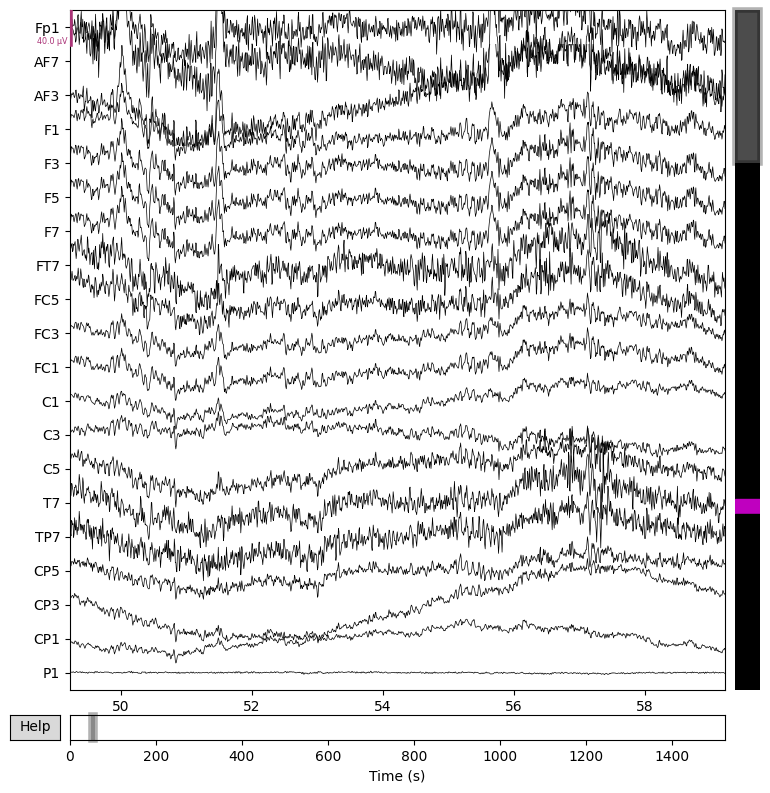

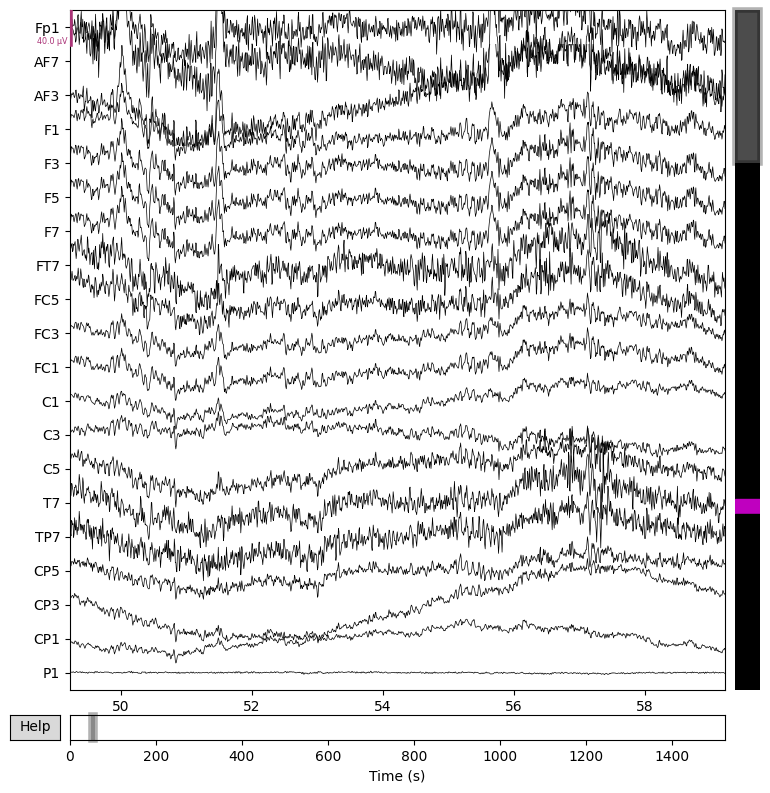

In [4]:
import mne
import numpy as np
import pandas as pd
import os
import glob
import pickle
import numpy as np
import pandas as pd

from scipy.signal import butter, filtfilt
# ── Παράμετροι ────────────────────────────────────────────────────────────
TMIN     = -3.0   # 2.5 δευτερόλεπτα πριν το onset
TMAX     =  0.0   # ακριβώς στο onset
MIN_SPACING = 3.0  # seconds
CSV_PATH = r"E:\koorathota_data\pkl_data\pkl_data\pkl_data\turns\ALL_SUBJECTS_VIS_CURVE_UNIVERSAL.csv"
file_path = r"E:\koorathota_data\pkl_data\pkl_data\pkl_data\Copy of 08_25_2022_10_32_35-Exp_adadrive-Sbj_12-Ssn_01.dats-025.pkl"
# ── Φόρτωση onsets ────────────────────────────────────────────────────────
df_universal = pd.read_csv(CSV_PATH)
print(f"Total reversal events: {len(df_universal)}")

# ── Φόρτωση raw EEG (BioSemi) ─────────────────────────────────────────────
with open(file_path, "rb") as f:
    data = pickle.load(f)
raw,raw_t0=createRaw(data)
eeg_sfreq = raw.info["sfreq"]

print(f"\nMNE Raw created successfully:")
print(f"  Sfreq    : {raw.info['sfreq']:.2f} Hz")
print(f"  Duration : {raw.times[-1]:.2f}s")
print(f"  Channels : {raw.info['nchan']}")
trial,trial_timestamps = data["Unity_TrialInfo"]
subject_id= trial[0][0]
session_id = trial[1][0]

df_sess = df_universal[
    (df_universal['subject_id'] == subject_id) &
    (df_universal['session_id'] == session_id)
].copy()
# ── Events array ──────────────────────────────────────────────────────────


df_sess = df_sess.sort_values("onset_time_s")

keep = [True]

for i in range(1, len(df_sess)):
    dt = (
        df_sess.iloc[i]["onset_time_s"] -
        df_sess.iloc[i-1]["onset_time_s"]
    )
    keep.append(dt >= MIN_SPACING)

df_sess = df_sess[np.array(keep)]

raw_epochs = raw.copy().pick('eeg')
epochs = epochsCreation(
    df_sess,
    raw_epochs,
    raw_t0,
    tmin=TMIN,
    tmax=TMAX
)
print(epochs.drop_log[:10])
print(f"\nEpochs shape : {epochs.get_data().shape}")
print(f"  n_epochs   : {len(epochs)}")
print(f"  n_channels : {len(epochs.ch_names)}")
print(f"  n_times    : {len(epochs.times)}")
print(f"  tmin/tmax  : {epochs.tmin:.1f}s / {epochs.tmax:.1f}s")
print(f"  sfreq      : {epochs.info['sfreq']:.2f} Hz")
print(f"\nMetadata sample:")
print(epochs.metadata.head(3))
event_time = df_sess.iloc[0]["onset_time_s"]

print("Behavioral onset:", event_time)
print("EEG start:", raw_t0)

sample = int(round((event_time - raw_t0) * raw.info['sfreq']))

print("Sample:", sample)
print("Time from sample:", sample / raw.info['sfreq'])
raw.plot(
    start=(sample/raw.info['sfreq']) - 5,
    duration=10
)
# ── Αποθήκευση ────────────────────────────────────────────────────────────
#OUTPUT_PATH = '/home/thesisuser02/eeg_koorathota/eeg_preprocessing_pipeline/sterrin_detection_gap/epochs_large_reversals_sbj12_ssn01-epo.fif'
#epochs.save(OUTPUT_PATH, overwrite=True)
#print(f"\nSaved → {OUTPUT_PATH}")

# Επαλήθευση
#epochs_check = mne.read_epochs(OUTPUT_PATH, verbose=False)
#print(f"Verified: {len(epochs_check)} epochs, "
 #     f"{len(epochs_check.ch_names)} channels, "
  #    f"{len(epochs_check.times)} timepoints")

### Motor detection algorithm with minor changes in the steering reversal rate to comply with the fact that motorInput doesn't have a specific sampling rate and instead is interpolated in the sampling rate of the EEG for easier epoch creation

In [3]:
# !/usr/bin/env python
# coding: utf-8

import os
import glob
import pickle
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.signal import butter, filtfilt


# ─────────────────────────────────────────────────────────────
# Constants
# ─────────────────────────────────────────────────────────────
MAX_STEER_DEG = 450.0

BASE_PATH = r"E:\koorathota_data\pkl_data\pkl_data\pkl_data"

OUTPUT_DIR = r"E:\koorathota_data\pkl_data\pkl_data\pkl_data\turns"

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ─────────────────────────────────────────────────────────────
# Helper functions
# ─────────────────────────────────────────────────────────────
def deg_to_norm(deg):
    return deg / MAX_STEER_DEG


GAP_VIS_CUR = deg_to_norm(4.0)


def find_upward_reversals(steer_filt, extrema_idx, gap_size):
    """
    Εντοπισμός 'upward' reversals (local min → local max, διαφορά > gap_size).
    Μεταφρασμένο από το MATLAB FindUpwardReversals — Markkula & Engström (2006).
    """
    n = len(extrema_idx)
    i = 0
    reversals = []
    for j in range(1, n):
        delta = steer_filt[extrema_idx[j]] - steer_filt[extrema_idx[i]]
        if delta > gap_size:
            reversals.append([extrema_idx[i], extrema_idx[j]])
            i = j
        elif steer_filt[extrema_idx[j]] <= steer_filt[extrema_idx[i]]:
            i = j
    return np.array(reversals, dtype=int) if reversals else np.empty((0, 2), dtype=int)


def steering_reversal_rate(steer_deg, timestamps, gap_size_deg,
                            lpf_cutoff_hz=2.0, lpf_order=2,
                            resample_rate_hz=128):
    """
    Υπολογισμός Steering Wheel Reversal Rate (SWRR).
    Υλοποίηση του αλγορίθμου Markkula & Engström (2006) σε Python.

    Parameters
    ----------
    steer_deg        : 1-D array  — steering signal (normalized ή degrees)
    sample_rate_hz   : float      — δειγματοληπτικός ρυθμός εισόδου (Hz)
    gap_size_deg     : float      — ελάχιστο πλάτος reversal (same units as steer_deg)
    lpf_cutoff_hz    : float      — συχνότητα αποκοπής Butterworth LPF (Hz)
    lpf_order        : int        — τάξη Butterworth φίλτρου (default 2)
    resample_rate_hz : float/None — προαιρετικός νέος ρυθμός δειγματοληψίας

    Returns
    -------
    swrr       : float       — reversals per minute
    reversals  : (N,2) array — indices [start, end] κάθε reversal
    steer_filt : 1-D array   — φιλτραρισμένο σήμα
    t_resamp   : 1-D array   — timestamps (0-based, seconds)
    """
    steer_deg = np.asarray(steer_deg, dtype=float)

    t_orig = np.asarray(timestamps, dtype=float)

# make timestamps start at 0
    t_orig = t_orig - t_orig[0]

    duration_s = t_orig[-1]

 
    # ── Resample to uniform timeline ─────────────────────────────

    t_resamp = np.arange(
        0,
        duration_s,
        1.0 / resample_rate_hz
    )

    f_interp = interp1d(
        t_orig,
        steer_deg,
        kind='linear',
        bounds_error=False,
        fill_value='extrapolate'
    )

    steer_resamp = f_interp(t_resamp)

    fs = resample_rate_hz

    # ── Low-pass Butterworth φίλτρο ───────────────────────────────────────
    if lpf_cutoff_hz is not None:
        nyq  = fs / 2.0
        b, a = butter(lpf_order, lpf_cutoff_hz / nyq, btype='low')
        steer_filt = filtfilt(b, a, steer_resamp)
    else:
        steer_filt = steer_resamp.copy()

    # ── Εύρεση stationary points (Markkula & Engström, Eqs. 1 & 2) ───────
    # d[0]=0, d[i] = theta[i] - theta[i-1]  για i > 0
    T  = len(steer_filt)
    d  = np.zeros(T)
    d[1:] = np.diff(steer_filt)
    sign_d = np.sign(d)

    extrema_mask = np.zeros(T, dtype=bool)
    for i in range(1, T - 1):
        if d[i] == 0:                              # Equation 1
            extrema_mask[i] = True
        elif abs(sign_d[i] - sign_d[i + 1]) == 2: # Equation 2
            extrema_mask[i] = True

    extrema_idx = np.where(extrema_mask)[0]

    # ── Εύρεση reversals (upward + downward) ─────────────────────────────
    up   = find_upward_reversals( steer_filt, extrema_idx, gap_size_deg)
    down = find_upward_reversals(-steer_filt, extrema_idx, gap_size_deg)

    if len(up) > 0 and len(down) > 0:
        reversals = np.vstack([up, down])
        reversals = reversals[np.argsort(reversals[:,0])]
    elif len(up) > 0:
        reversals = up
    elif len(down) > 0:
        reversals = down
    else:
        reversals = np.empty((0, 2), dtype=int)

    swrr = len(reversals) / duration_s * 60.0

    return swrr, reversals, steer_filt, t_resamp

def build_reversal_df(
    reversals,
    steer_filt,
    t_abs,
    label
):

    if len(reversals) == 0:
        return pd.DataFrame()

    onsets = t_abs[
        reversals[:, 0]
    ]

    offsets = t_abs[
        reversals[:, 1]
    ]

    durations = offsets - onsets

    delta = (
        steer_filt[reversals[:, 1]]
        - steer_filt[reversals[:, 0]]
    )

    amp_norm = np.abs(delta)

    amp_deg = (
        amp_norm
        * MAX_STEER_DEG
    )

    direction = np.where(
        delta > 0,
        1,
        0
    )

    return pd.DataFrame({
        'label': label,
        'onset_time_s': onsets,
        'offset_time_s': offsets,
        'duration_s': durations,
        'amplitude_norm': amp_norm,
        'amplitude_deg': amp_deg,
        'direction': direction
    })


def get_fog_density_at_time(
    t,
    trial_timestamps,
    fog_density
):

    idx = np.searchsorted(
        trial_timestamps,
        t,
        side='right'
    ) - 1

    idx = np.clip(
        idx,
        0,
        len(fog_density) - 1
    )

    return fog_density[idx]


# ─────────────────────────────────────────────────────────────
# Find all PKL files
# ─────────────────────────────────────────────────────────────
pkl_files = glob.glob(
    os.path.join(BASE_PATH, "*.pkl")
)

print(f"Found {len(pkl_files)} PKL files")


# ─────────────────────────────────────────────────────────────
# Global containers
# ─────────────────────────────────────────────────────────────
all_vis_curve = []

all_vis_curve_p75 = []


# ─────────────────────────────────────────────────────────────
# Main loop
# ─────────────────────────────────────────────────────────────
for file_path in pkl_files:

    file_name = os.path.basename(file_path)

    print("\n" + "=" * 60)

    print(f"Processing: {file_name}")

    try:

        # ─────────────────────────────────
        # Load data
        # ─────────────────────────────────
        with open(file_path, "rb") as f:

            data = pickle.load(f)

        # ─────────────────────────────────
        # Motor data
        # ─────────────────────────────────
        motor_data, motor_timestamps = (
            data['Unity_MotorInput']
        )

        steering = motor_data[0, :]

        time = motor_timestamps

        

        # ─────────────────────────────────
        # Detect reversals
        # ─────────────────────────────────
        swrr_vis_c, reversals_vis_c, steer_filt_06hz, t_filt = steering_reversal_rate(
        steering,
        timestamps=time,
        gap_size_deg=GAP_VIS_CUR,
        lpf_cutoff_hz=0.6,
        lpf_order=2,
        resample_rate_hz=128
    )

        t_abs = t_filt + time[0]

        df_vis_c = build_reversal_df(
            reversals_vis_c,
            steer_filt_06hz,
            t_abs,
            'visual_curve'
        )
        df_vis_c =  df_vis_c.sort_values('onset_time_s')

        if len(df_vis_c) == 0:

            print("No reversals found")

            continue

        # ─────────────────────────────────
        # Subject/session info
        # ─────────────────────────────────
        trial_data, trial_timestamps = (
            data['Unity_TrialInfo']
        )

        fog_density = trial_data[5, :]

        subject_id = int(
            trial_data[0, 0]
        )

        session_id = int(
            trial_data[1, 0]
        )

        # ─────────────────────────────────
        # Add metadata
        # ─────────────────────────────────
        df_vis_c['fog_density'] = (
            df_vis_c['onset_time_s']
            .apply(
                lambda t:
                get_fog_density_at_time(
                    t,
                    trial_timestamps,
                    fog_density
                )
            )
        )

        df_vis_c['subject_id'] = subject_id

        df_vis_c['session_id'] = session_id

        # ─────────────────────────────────
        # P75 filtering
        # ─────────────────────────────────
        threshold = np.percentile(
            df_vis_c['amplitude_deg'],
            75
        )

        df_large = df_vis_c[
            df_vis_c['amplitude_deg']
            >= threshold
        ].copy()

        print(f"Total reversals : {len(df_vis_c)}")

        print(f"P75 threshold   : {threshold:.2f}°")

        print(f"P75 reversals   : {len(df_large)}")

        # ─────────────────────────────────
        # Save subject/session files
        # ─────────────────────────────────
       # out_all = os.path.join(
        #    OUTPUT_DIR,
         #   f"Sbj{subject_id:02d}_Ssn{session_id:02d}_VIS_CURVE_ALL.csv"
        #)

        #out_p75 = os.path.join(
         #   OUTPUT_DIR,
          #  f"Sbj{subject_id:02d}_Ssn{session_id:02d}_VIS_CURVE_P75.csv"
        #)

        #df_vis_c.to_csv(
         #   out_all,
          #  index=False
      #  )

       # df_large.to_csv(
        #    out_p75,
         #   index=False
        #)

        #print(f"Saved: {out_all}")

        #print(f"Saved: {out_p75}")

        # ─────────────────────────────────
        # Store globally
        # ─────────────────────────────────
        all_vis_curve.append(df_vis_c)

        all_vis_curve_p75.append(df_large)

    except Exception as e:

        print(f"Error processing {file_name}: {e}")


# ─────────────────────────────────────────────────────────────
# Combine ALL subjects
# ─────────────────────────────────────────────────────────────
if len(all_vis_curve) > 0:

    combined_all = pd.concat(
        all_vis_curve,
        ignore_index=True
    )

    combined_p75 = pd.concat(
        all_vis_curve_p75,
        ignore_index=True
    )

    combined_all_path = os.path.join(
        OUTPUT_DIR,
        "ALL_SUBJECTS_VIS_CURVE_ALL.csv"
    )

    combined_p75_path = os.path.join(
        OUTPUT_DIR,
        "ALL_SUBJECTS_VIS_CURVE_P75.csv"
    )

    combined_all.to_csv(
        combined_all_path,
        index=False
    )

    combined_p75.to_csv(
        combined_p75_path,
        index=False
    )

    print("\n" + "=" * 60)

    print("FINAL SUMMARY")

    print(f"Combined ALL saved : {combined_all_path}")

    print(f"Combined P75 saved : {combined_p75_path}")

    print(f"Total ALL reversals : {len(combined_all)}")

    print(f"Total P75 reversals : {len(combined_p75)}")

Found 30 PKL files

Processing: Copy of 08_25_2022_10_32_35-Exp_adadrive-Sbj_12-Ssn_01.dats-025.pkl
Total reversals : 568
P75 threshold   : 149.65°
P75 reversals   : 142
Saved: E:\koorathota_data\pkl_data\pkl_data\pkl_data\turns\Sbj12_Ssn01_VIS_CURVE_ALL.csv
Saved: E:\koorathota_data\pkl_data\pkl_data\pkl_data\turns\Sbj12_Ssn01_VIS_CURVE_P75.csv

Processing: Copy of 08_26_2022_11_53_52-Exp_adadrive-Sbj_12-Ssn_02.dats-028.pkl
Total reversals : 888
P75 threshold   : 146.34°
P75 reversals   : 222
Saved: E:\koorathota_data\pkl_data\pkl_data\pkl_data\turns\Sbj12_Ssn02_VIS_CURVE_ALL.csv
Saved: E:\koorathota_data\pkl_data\pkl_data\pkl_data\turns\Sbj12_Ssn02_VIS_CURVE_P75.csv

Processing: Copy of 09_02_2022_10_34_48-Exp_adadrive-Sbj_12-Ssn_03.dats.pkl
Total reversals : 636
P75 threshold   : 122.67°
P75 reversals   : 159
Saved: E:\koorathota_data\pkl_data\pkl_data\pkl_data\turns\Sbj12_Ssn03_VIS_CURVE_ALL.csv
Saved: E:\koorathota_data\pkl_data\pkl_data\pkl_data\turns\Sbj12_Ssn03_VIS_CURVE_P75.cs

In [4]:

CSV_PATH = r"E:\koorathota_data\pkl_data\pkl_data\pkl_data\turns\ALL_SUBJECTS_VIS_CURVE_ALL.csv"


df = pd.read_csv(CSV_PATH)

print(df.head())

          label  onset_time_s  offset_time_s  duration_s  amplitude_norm  \
0  visual_curve   3889.732156    3891.169656    1.437500        0.027885   
1  visual_curve   3891.169656    3894.474344    3.304688        0.049624   
2  visual_curve   3894.474344    3896.263406    1.789062        0.190814   
3  visual_curve   3896.263406    3899.763406    3.500000        0.287251   
4  visual_curve   3899.763406    3900.958719    1.195312        0.067316   

   amplitude_deg  direction  fog_density  subject_id  session_id  
0      12.548250          1          0.0          12           1  
1      22.330596          0          0.0          12           1  
2      85.866125          1          0.0          12           1  
3     129.262820          0          0.0          12           1  
4      30.292058          1          0.0          12           1  


#### Deciding a universal thresholp using the p75

=== Global amplitude statistics ===
p50: 63.57°
p75: 123.60°
p80: 138.85°
p85: 158.25°
p90: 185.34°
p95: 241.76°
Mean : 89.74°
Std  : 96.58°
Max  : 920.05°


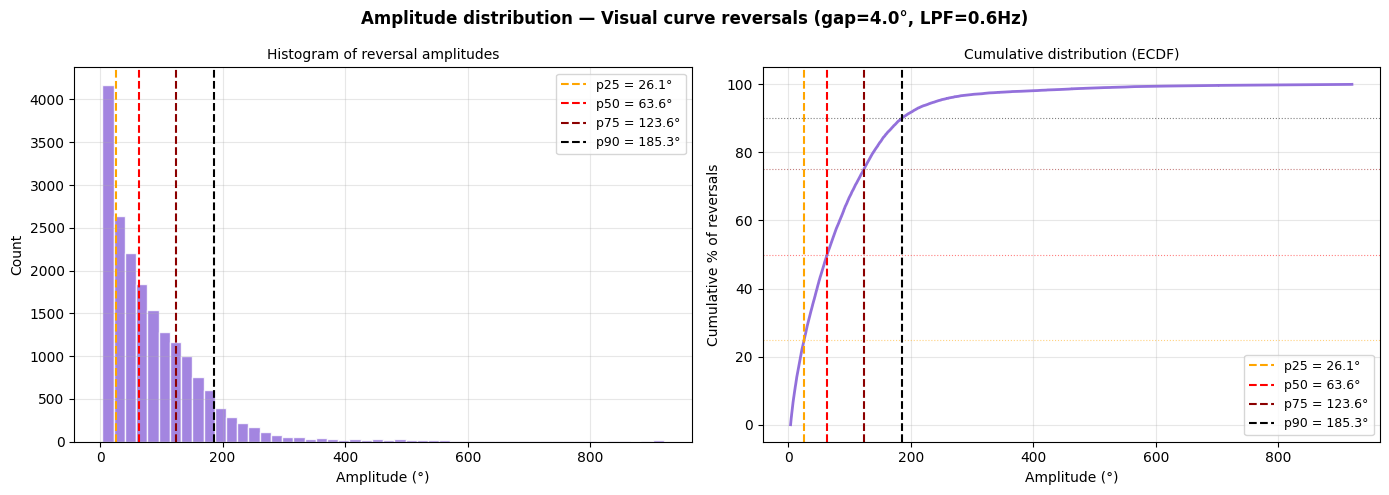

=== Amplitude statistics (degrees) ===
  p25:   26.13°
  p50:   63.57°
  p75:  123.60°
  p90:  185.34°
  p95:  241.76°
  mean:   89.74°
  max:   920.05°
  min:     4.00°


In [5]:
# Χρησιμοποιούμε το visual_curve dataset (gap=4.0°, LPF=0.6Hz)
# που ήδη έχουμε από την Cell 4
import matplotlib.pyplot as plt
amps_deg = df['amplitude_deg'].values

print("=== Global amplitude statistics ===")

for pct in [50, 75, 80, 85, 90, 95]:
    print(f"p{pct}: {np.percentile(amps_deg, pct):.2f}°")

print(f"Mean : {amps_deg.mean():.2f}°")
print(f"Std  : {amps_deg.std():.2f}°")
print(f"Max  : {amps_deg.max():.2f}°")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Amplitude distribution — Visual curve reversals (gap=4.0°, LPF=0.6Hz)',
             fontsize=12, fontweight='bold')

# ── Histogram ─────────────────────────────────────────────────────────────
axes[0].hist(amps_deg, bins=50, color='mediumpurple', edgecolor='white',
             alpha=0.85)
axes[0].set_xlabel('Amplitude (°)', fontsize=10)
axes[0].set_ylabel('Count', fontsize=10)
axes[0].set_title('Histogram of reversal amplitudes', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Percentile lines
for pct, color in [(25,'orange'), (50,'red'), (75,'darkred'), (90,'black')]:
    val = np.percentile(amps_deg, pct)
    axes[0].axvline(x=val, color=color, lw=1.5, linestyle='--',
                    label=f'p{pct} = {val:.1f}°')
axes[0].legend(fontsize=9)

# ── ECDF ───────────────────────────────────────────────────────────────────
sorted_amps = np.sort(amps_deg)
ecdf        = np.arange(1, len(sorted_amps)+1) / len(sorted_amps)
axes[1].plot(sorted_amps, ecdf * 100, color='mediumpurple', lw=2)
axes[1].set_xlabel('Amplitude (°)', fontsize=10)
axes[1].set_ylabel('Cumulative % of reversals', fontsize=10)
axes[1].set_title('Cumulative distribution (ECDF)', fontsize=10)
axes[1].grid(True, alpha=0.3)

for pct, color in [(25,'orange'), (50,'red'), (75,'darkred'), (90,'black')]:
    val = np.percentile(amps_deg, pct)
    axes[1].axvline(x=val, color=color, lw=1.5, linestyle='--',
                    label=f'p{pct} = {val:.1f}°')
    axes[1].axhline(y=pct, color=color, lw=0.8, linestyle=':', alpha=0.5)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Descriptive stats ──────────────────────────────────────────────────────
print("=== Amplitude statistics (degrees) ===")
for pct in [25, 50, 75, 90, 95]:
    print(f"  p{pct:2d}: {np.percentile(amps_deg, pct):7.2f}°")
print(f"  mean: {amps_deg.mean():7.2f}°")
print(f"  max:  {amps_deg.max():7.2f}°")
print(f"  min:  {amps_deg.min():7.2f}°")

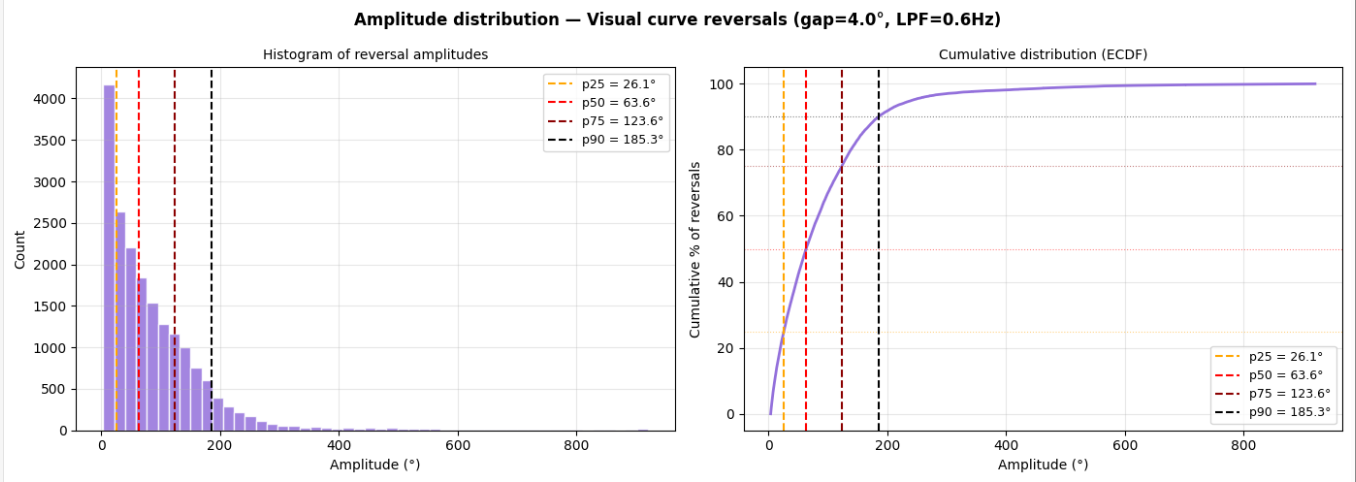

=== Amplitude statistics (degrees) ===
  p25:   26.13°
  p50:   63.57°
  p75:  123.60°
  p90:  185.34°
  p95:  241.76°
  mean:   89.74°
  max:   920.05°
  min:     4.00°

In [6]:
UNIVERSAL_THRESHOLD = np.percentile(amps_deg, 75)


df_global = df[
    df['amplitude_deg'] >= UNIVERSAL_THRESHOLD
].copy()

print(f"Universal threshold: {UNIVERSAL_THRESHOLD:.2f}°")
print(f"Events retained: {len(df_global)}")
print(f"Percent retained: {100 * len(df_global)/len(df):.1f}%")

Universal threshold: 123.60°
Events retained: 4766
Percent retained: 25.0%


In [7]:
OUT_PATH = r"E:\koorathota_data\pkl_data\pkl_data\pkl_data\eegdata\ALL_SUBJECTS_VIS_CURVE_UNIVERSAL.csv"


df_global.to_csv(OUT_PATH, index=False)

print(f"Saved: {OUT_PATH}")

Saved: E:\koorathota_data\pkl_data\pkl_data\pkl_data\eegdata\ALL_SUBJECTS_VIS_CURVE_UNIVERSAL.csv
